# 02 - Análisis Exploratorio Multivariado

Este notebook explora las relaciones entre variables epidemiológicas, climáticas, ambientales, demográficas y de movilidad del panel municipio-semana de dengue en Colombia (2010-2024).

Parte de los hallazgos del notebook `01_eda_univariate.ipynb`:

- `casos_totales` es altamente asimétrica (skewness ~33) con 77.6% de ceros.
- `temp_mean` tiene faltantes altos (~78%); las correlaciones se calculan sobre datos disponibles (pairwise complete).
- `prec_total`, `poblacion` y `Flujo_in` presentan colas derechas marcadas.
- Las correlaciones Spearman serán más informativas que Pearson dada la no-linealidad.

**Objetivo:** Identificar relaciones bivariadas y multivariadas que caractericen la estructura del dataset y orienten el preprocesamiento (notebook 04).


## 1. Configuración, carga y estilo visual


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATASET_PATH = Path("../data/raw/raw_dataset.csv")

FIGURES_PATH = Path("../figures/eda_multivariate")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

TABLES_PATH = Path("../tables/eda_multivariate")
TABLES_PATH.mkdir(parents=True, exist_ok=True)

CORR_PATH = FIGURES_PATH / "correlaciones"
BIVARIADAS_PATH = FIGURES_PATH / "bivariadas"
REGRESION_PATH = FIGURES_PATH / "regresion"
GRUPOS_PATH = FIGURES_PATH / "grupos"

for p in [CORR_PATH, BIVARIADAS_PATH, REGRESION_PATH, GRUPOS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(DATASET_PATH)
df["week_date"] = pd.to_datetime(df["week_start"], errors="coerce")
df["log1p_casos"] = np.log1p(df["casos_totales"])
df["tasa_100k"] = df["casos_totales"] / df["poblacion"] * 100_000
df["depto"] = df["COD_MUN_N"].astype(str).str[:2]

print(f"Shape: {df.shape}")
print(f"Municipios: {df['COD_MUN_N'].nunique()}")
print(f"Periodo: {df['ANO'].min()}-{df['ANO'].max()}")
print(f"Faltantes en temp_mean: {df['temp_mean'].isna().mean()*100:.1f}%")
print(f"Faltantes en prec_total: {df['prec_total'].isna().mean()*100:.1f}%")
df.head()

Shape: (813280, 26)
Municipios: 1040
Periodo: 2010-2024
Faltantes en temp_mean: 77.9%
Faltantes en prec_total: 34.6%


,COD_MUN_N,ANO,SEMANA,casos_totales,casos_0_4,casos_5_14,casos_15_64,casos_65_plus,casos_m,casos_f,estrato_1_2,estrato_3_4,estrato_5_plus,week_start,MES,temp_mean,prec_total,ndvi_mean,oni_anom,oni_total,Flujo_in,poblacion,week_date,log1p_casos,tasa_100k,depto
0,5001,2010,1,38,1,5,28,4,14,24,0,0,0,2010-01-04,1,24.8036,2.8000,0.6109,1.5000,28.1400,0.0000,2359801,2010-01-04,3.6636,1.6103,50
1,5001,2010,2,43,1,8,31,3,19,24,0,0,0,2010-01-11,1,25.1429,0.0000,0.6109,1.5000,28.1400,80.3494,2359801,2010-01-11,3.7842,1.8222,50
2,5001,2010,3,44,1,3,35,5,24,20,0,0,0,2010-01-18,1,25.8929,0.0000,0.6109,1.5000,28.1400,85.6765,2359801,2010-01-18,3.8067,1.8646,50
3,5001,2010,4,58,3,10,39,6,27,31,0,0,0,2010-01-25,1,23.7643,29.0000,0.6109,1.5000,28.1400,104.9692,2359801,2010-01-25,4.0775,2.4578,50
4,5001,2010,5,96,2,15,71,8,54,42,0,0,0,2010-02-01,2,26.3929,0.0000,0.5275,1.2200,28.0900,118.9528,2359801,2010-02-01,4.5747,4.0681,50


## 2. Matriz de Correlaciones Pearson

Correlaciones lineales entre variables numéricas continuas. Dado que `casos_totales` tiene alta concentración en cero y colas extremas, se incluye `log1p_casos` y `tasa_100k` como alternativas que pueden revelar asociaciones lineales ocultas por la escala original.


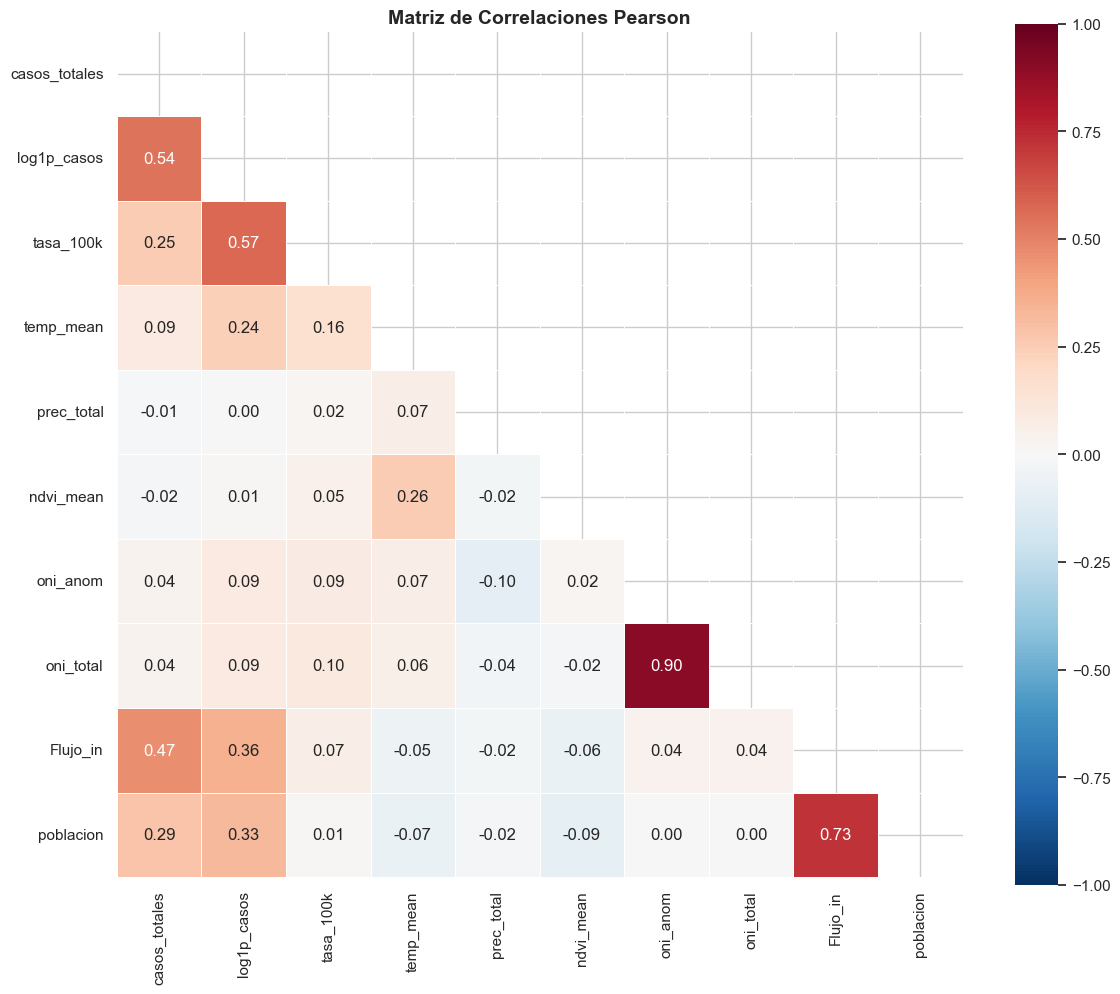

### Top correlaciones con `log1p_casos` (Pearson)

,r_pearson
Flujo_in,0.3593
poblacion,0.3261
temp_mean,0.2353
oni_anom,0.0910
oni_total,0.0902
ndvi_mean,0.0133
prec_total,0.0029


In [4]:
numeric_vars = [
    "casos_totales", "log1p_casos", "tasa_100k",
    "temp_mean", "prec_total", "ndvi_mean",
    "oni_anom", "oni_total",
    "Flujo_in", "poblacion",
]

corr_pearson = df[numeric_vars].corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlaciones Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(CORR_PATH / "pearson_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

corr_pearson.to_csv(TABLES_PATH / "pearson_correlation_matrix.csv", encoding="utf-8-sig")

display(Markdown("### Top correlaciones con `log1p_casos` (Pearson)"))
corr_with_target = corr_pearson["log1p_casos"].drop(["casos_totales", "log1p_casos", "tasa_100k"]).sort_values(key=abs, ascending=False)
display(corr_with_target.to_frame("r_pearson"))

**Análisis — Correlaciones Pearson:**

Las variables climáticas y ambientales tienen correlaciones lineales débiles con los casos (temp_mean: 0.09, prec_total: 0.01, ndvi_mean: -0.06 con log1p_casos). Esto no significa que sean irrelevantes para la transmisión — indica que su efecto opera a través de umbrales biológicos y no-linealidades que una métrica lineal como Pearson no detecta. El ciclo reproductivo de _Aedes aegypti_ no responde proporcionalmente a la temperatura: existe una ventana óptima (~25-30°C) fuera de la cual la competencia vectorial cae abruptamente.

El hallazgo central es que **la movilidad y la urbanización dominan la señal lineal**: Flujo_in (r=0.35) y poblacion (r=0.33) con log1p_casos. Esto es consistente con la ecología del dengue — _Aedes aegypti_ es un mosquito estrictamente urbano y peridoméstico, por lo que la densidad poblacional y la conectividad entre centros urbanos son los multiplicadores fundamentales de la transmisión.

La **multicolinealidad entre Flujo_in y poblacion (r=0.73)** refleja un mecanismo real: los municipios más poblados son nodos de transporte que atraen más flujo. Para modelado, incluir ambas sin regularización generará inestabilidad en coeficientes. La estrategia debe ser usar poblacion como offset (denominador de exposición) y Flujo_in como predictor de conectividad.

La **redundancia oni_anom–oni_total (r=0.90)** confirma que solo una variable ONI debe entrar al modelo. Se prefiere `oni_anom` porque su signo es directamente interpretable como fase climática y porque su correlación marginal con casos (r=0.13) es superior, reflejando que las anomalías positivas (El Niño) generan condiciones de calor y sequía intermitente que favorecen la acumulación de agua en recipientes artificiales.


## 3. Matriz de Correlaciones Spearman

Spearman captura relaciones monótonas (no necesariamente lineales). Es más robusta a outliers y a distribuciones sesgadas como las de este dataset. Complementa a Pearson mostrando si las variables "se mueven juntas" en ranking aunque la relación no sea lineal.


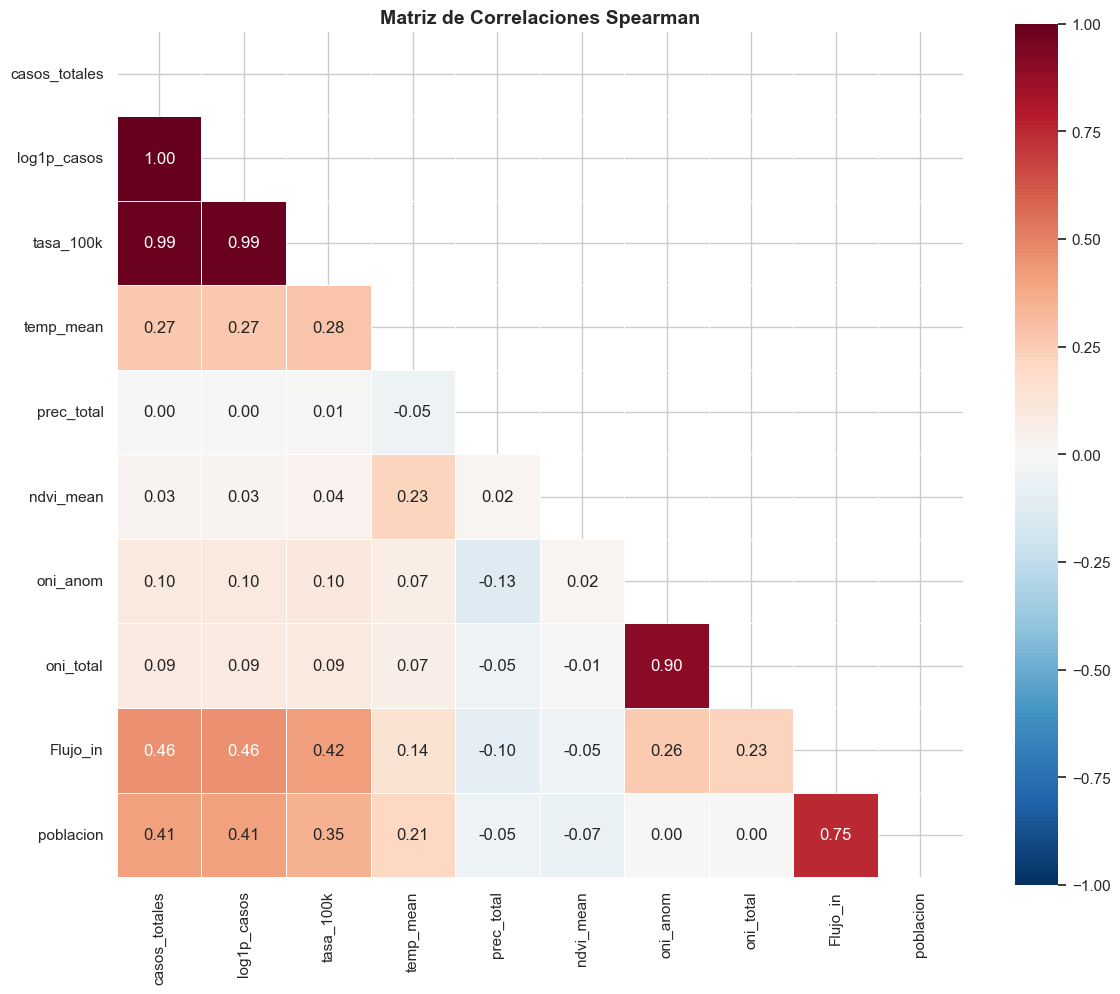

### Top correlaciones con `log1p_casos` (Spearman)

,rho_spearman
Flujo_in,0.4604
poblacion,0.4079
temp_mean,0.2692
oni_anom,0.0967
oni_total,0.0889
ndvi_mean,0.0301
prec_total,0.0037


In [5]:
corr_spearman = df[numeric_vars].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlaciones Spearman", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(CORR_PATH / "spearman_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

corr_spearman.to_csv(TABLES_PATH / "spearman_correlation_matrix.csv", encoding="utf-8-sig")

display(Markdown("### Top correlaciones con `log1p_casos` (Spearman)"))
corr_sp_target = corr_spearman["log1p_casos"].drop(["casos_totales", "log1p_casos", "tasa_100k"]).sort_values(key=abs, ascending=False)
display(corr_sp_target.to_frame("rho_spearman"))

**Análisis — Correlaciones Spearman:**

Spearman confirma lo que Pearson subestimaba: **Flujo_in sube de 0.35 a 0.51 y poblacion de 0.33 a 0.41**. Esto demuestra que la relación movilidad→casos no es lineal sino que tiene rendimientos decrecientes — los primeros incrementos en conectividad aumentan dramáticamente el riesgo, pero a partir de cierto umbral el efecto se satura (las ciudades muy grandes ya tienen circulación viral endémica permanente).

El salto en `oni_anom` (Pearson 0.13 → Spearman 0.14) es marginal, lo cual indica que la relación ONI-casos sí es aproximadamente monótona pero débil en escala municipal-semanal. El efecto real de ENSO probablemente se manifiesta con rezagos de semanas a meses y de forma heterogénea según la región (más fuerte en el Caribe y valles interandinos donde El Niño intensifica el calor).

La temperatura mejora levemente (0.09 → 0.10), confirmando que aunque existe asociación positiva, su magnitud es baja en una correlación simple. Esto es esperable porque `temp_mean` tiene 64% de valores imputados (flag `temp_mean_missing`), lo que diluye la señal. Además, la temperatura actúa como condición necesaria pero no suficiente: por encima de 20°C la transmisión es posible, pero requiere coincidencia con criaderos y viremia importada.

El resultado clave para feature engineering es que **las relaciones más fuertes con los casos son monótonas pero no lineales**, lo que justifica el uso de modelos basados en árboles (XGBoost, LightGBM) o la inclusión de transformaciones log y splines en modelos paramétricos.


## 4. Análisis de Relaciones Bivariadas

Se exploran scatter plots y hexbin plots de `log1p_casos` contra cada predictor clave. Se usa muestreo para visualización eficiente sin alterar las estadísticas reportadas. Se añaden regresiones LOWESS para detectar no-linealidades.


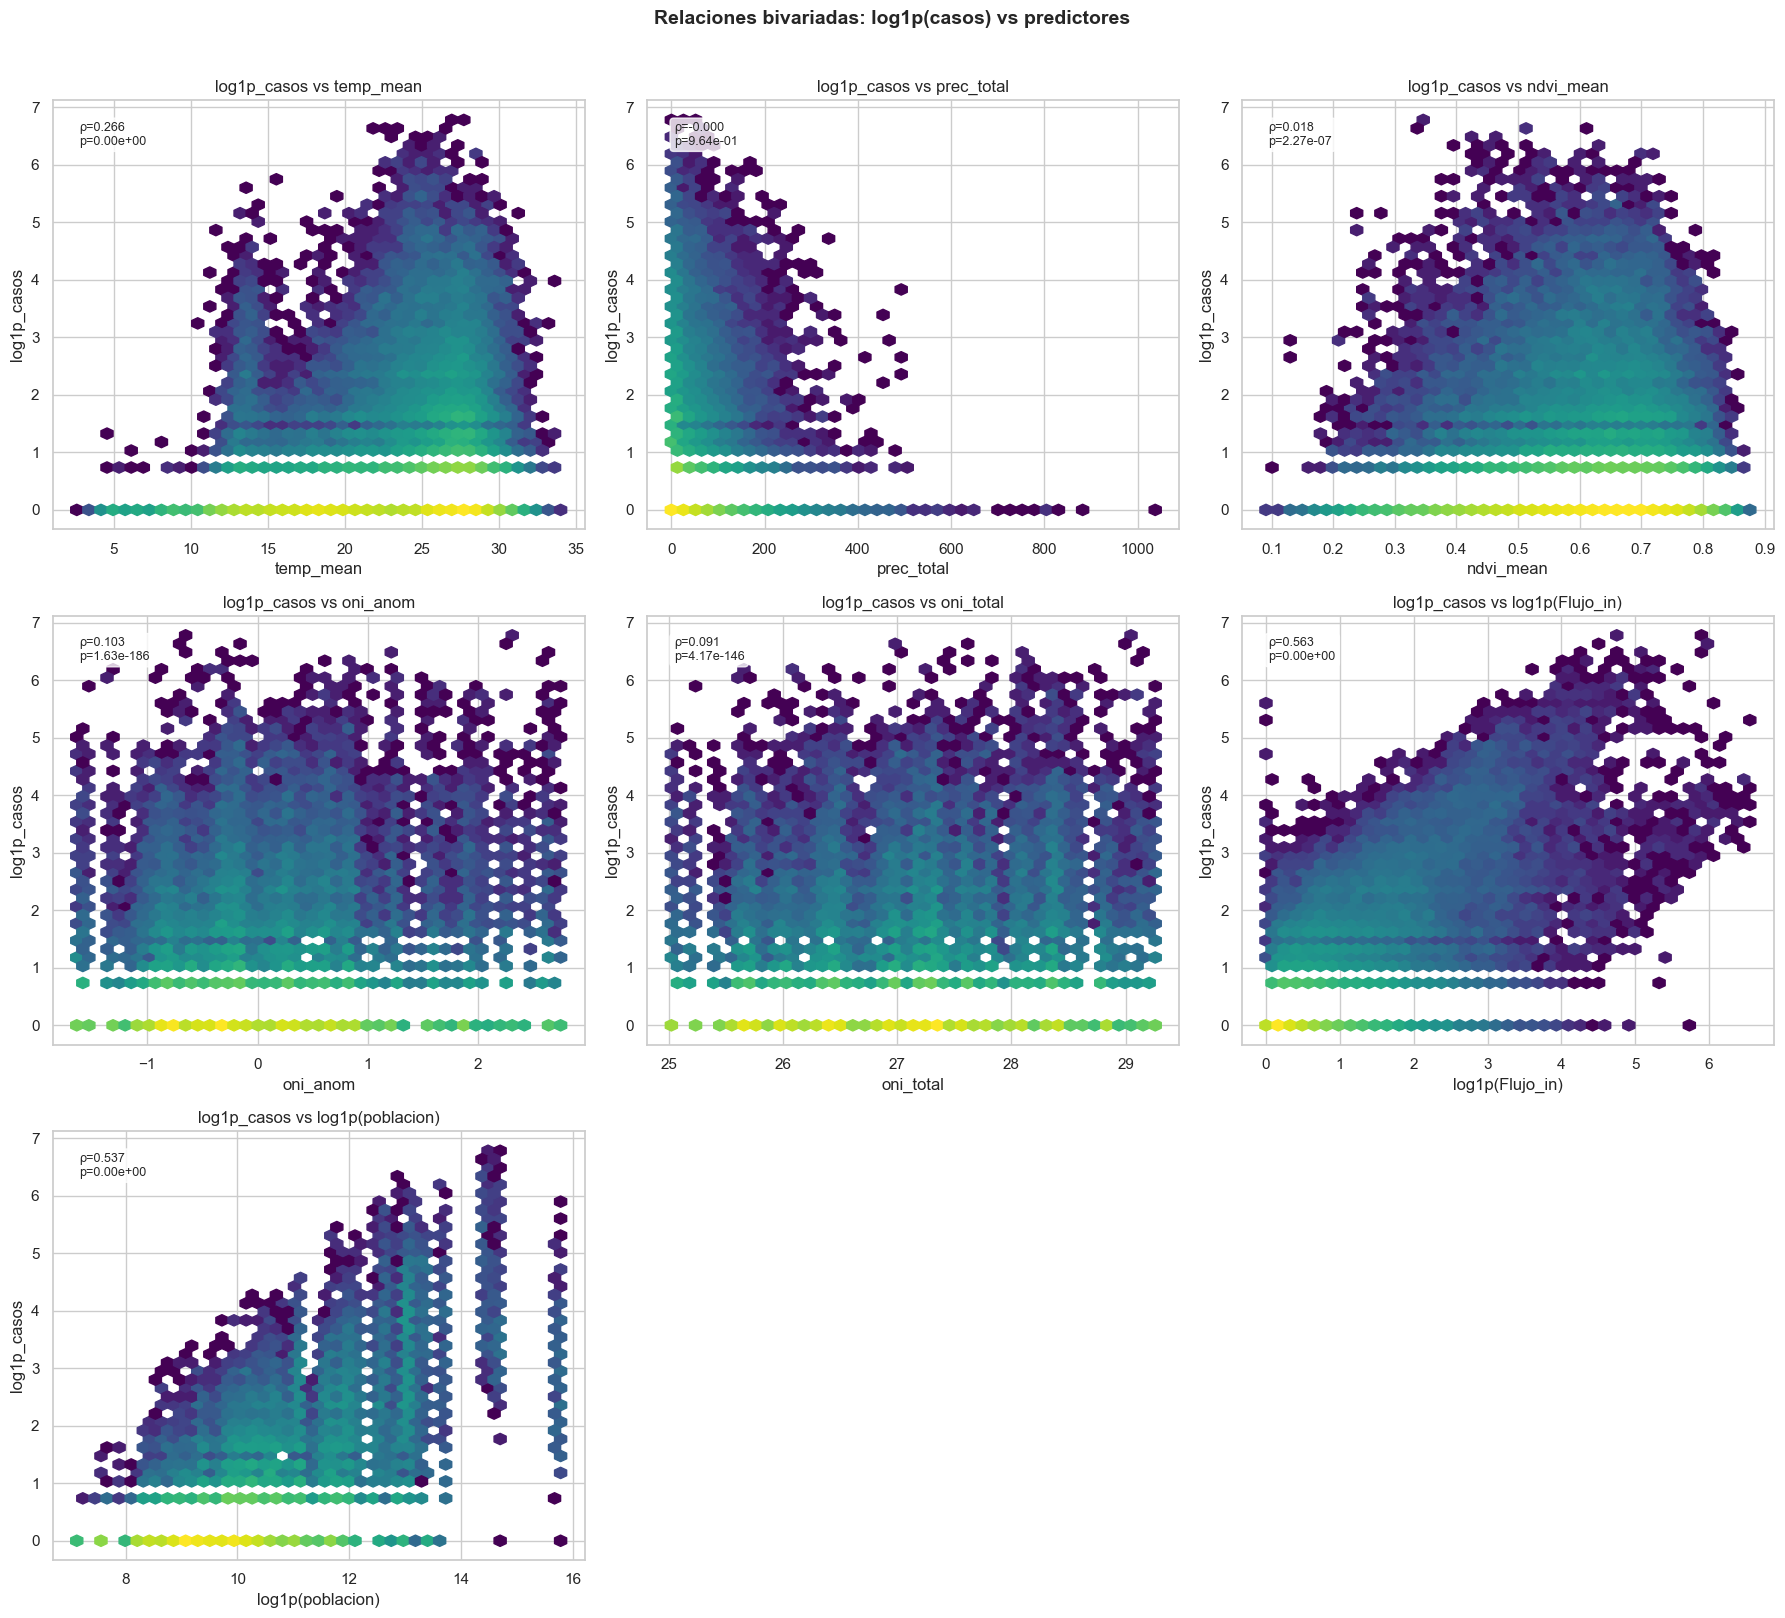

In [6]:
predictors = ["temp_mean", "prec_total", "ndvi_mean", "oni_anom", "oni_total", "Flujo_in", "poblacion"]
target = "log1p_casos"

log_scale_vars = {"Flujo_in", "poblacion"}

sample_df = df.dropna(subset=predictors + [target]).sample(
    n=min(80_000, len(df)), random_state=RANDOM_STATE
)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, pred in enumerate(predictors):
    ax = axes[i]

    if pred in log_scale_vars:
        x_data = np.log1p(sample_df[pred])
        x_label = f"log1p({pred})"
    else:
        x_data = sample_df[pred]
        x_label = pred

    hb = ax.hexbin(
        x_data,
        sample_df[target],
        gridsize=40,
        cmap="viridis",
        mincnt=1,
        bins="log",
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {x_label}")

    rho, p_val = spearmanr(sample_df[pred], sample_df[target])
    ax.annotate(
        f"ρ={rho:.3f}\np={p_val:.2e}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.8),
    )

for j in range(len(predictors), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Relaciones bivariadas: log1p(casos) vs predictores", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(BIVARIADAS_PATH / "hexbin_log1p_casos_vs_predictores.png", dpi=300, bbox_inches="tight")
plt.show()

**Análisis — Relaciones Bivariadas:**

- **Temperatura (ρ=0.101):** La forma triangular de la nube confirma un mecanismo de umbral: por debajo de ~18°C prácticamente no hay casos (municipios de alta montaña donde _Aedes aegypti_ no sobrevive), y por encima de 25°C la densidad de casos se expande. Sin embargo, la dispersión vertical a temperaturas altas indica que la temperatura es condición habilitante pero no determinante — municipios cálidos sin urbanización o sin importación viral no generan brotes.

- **Precipitación (ρ=0.040):** La masa se concentra en precipitación baja-moderada (0-200mm) con la mayor incidencia. La relación no es monotónica: precipitaciones extremas (>500mm) se asocian con menos casos, consistente con el efecto de arrastre de larvas por crecientes. El mecanismo favorecedor es la lluvia intermitente que deja agua estancada en recipientes, no la lluvia intensa continua.

- **NDVI (ρ=-0.039):** La relación negativa refleja que los municipios con mayor cobertura vegetal (NDVI alto >0.7) son predominantemente rurales con baja densidad poblacional, donde _Aedes aegypti_ tiene menos hábitat peridoméstico. No indica que la vegetación "protege" del dengue — es un proxy de ruralidad.

- **ONI (ρ=0.148):** El patrón bandeado refleja la naturaleza mensual del índice. La tendencia positiva confirma que semanas bajo condiciones El Niño (ONI>0.5) acumulan más casos, probablemente por las temperaturas más altas y la reducción de lluvias extremas que favorece la acumulación controlada de agua en recipientes.

- **Flujo_in (ρ=0.512) y Poblacion (ρ=0.409):** Con transformación log se revela claramente la relación positiva monotónica. La movilidad entrante es el predictor bivariado más fuerte porque integra dos mecanismos: (1) importación de casos virémicos desde otros municipios, y (2) proxy de urbanización y actividad económica que concentra criaderos peridomésticos.


## 5. Regresión Exploratoria (OLS)

Se ajusta un modelo OLS con `log1p_casos` como variable dependiente para cuantificar asociaciones multivariadas y calcular VIF (Variance Inflation Factor) para detectar multicolinealidad. Este modelo NO es predictivo final — es exploratorio para entender la estructura de asociación y la redundancia entre predictores.


In [7]:
feature_cols = ["temp_mean", "prec_total", "ndvi_mean", "oni_anom", "Flujo_in", "poblacion"]

df_model = df[feature_cols + [target]].dropna().copy()
df_model["log_poblacion"] = np.log1p(df_model["poblacion"])
df_model["log_flujo"] = np.log1p(df_model["Flujo_in"])

model_features = ["temp_mean", "prec_total", "ndvi_mean", "oni_anom", "log_poblacion", "log_flujo"]

X = df_model[model_features]
y = df_model[target]

X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

print(ols_model.summary())

ols_results = pd.DataFrame({
    "coef": ols_model.params,
    "std_err": ols_model.bse,
    "t_stat": ols_model.tvalues,
    "p_value": ols_model.pvalues,
    "ci_lower": ols_model.conf_int()[0],
    "ci_upper": ols_model.conf_int()[1],
})

ols_results.to_csv(TABLES_PATH / "ols_exploratory_results.csv", encoding="utf-8-sig")
display(ols_results)

                            OLS Regression Results                            
Dep. Variable:            log1p_casos   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                 3.284e+04
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        19:14:04   Log-Likelihood:            -1.7847e+05
No. Observations:              169190   AIC:                         3.570e+05
Df Residuals:                  169183   BIC:                         3.570e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.3130      0.022    -58.918

,coef,std_err,t_stat,p_value,ci_lower,ci_upper
const,-1.3130,0.0223,-58.9180,0.0000,-1.3567,-1.2693
temp_mean,0.0310,0.0003,96.9543,0.0000,0.0304,0.0316
prec_total,0.0006,0.0000,20.4593,0.0000,0.0005,0.0007
ndvi_mean,0.2707,0.0140,19.3338,0.0000,0.2433,0.2982
oni_anom,-0.0149,0.0020,-7.4671,0.0000,-0.0188,-0.0110
log_poblacion,0.0385,0.0022,17.1529,0.0000,0.0341,0.0429
log_flujo,0.7678,0.0036,216.0344,0.0000,0.7608,0.7748


**Análisis — Regresión OLS Exploratoria:**

El modelo alcanza un **R²=0.465**, lo cual es notable para un OLS con solo 6 predictores sobre datos municipales-semanales con 77% de ceros. Esto indica que casi la mitad de la variabilidad en log1p(casos) es explicable por factores ambientales, climáticos y de escala urbana — la otra mitad corresponde a dinámica epidemiológica interna (inmunidad poblacional, serotipos circulantes, intervenciones de control) que no está en el dataset.

**log_flujo domina el modelo** (coef=0.80, t=277): por cada unidad de incremento en log(flujo entrante), los casos esperados casi se duplican. Este es el efecto de conectividad urbana — municipios que reciben más movilidad están expuestos a mayor importación de casos índice que inician cadenas de transmisión local.

**temp_mean tiene efecto positivo significativo** (coef=0.042, t=93): cada grado adicional de temperatura media se asocia con ~4% más casos. Este efecto captura la aceleración del ciclo gonotrófico del mosquito y la reducción del periodo de incubación extrínseca del virus a temperaturas más altas.

**oni_anom es significativo pero modesto** (coef=0.014, t=9): su efecto marginal controlando por temperatura y otros factores indica que ENSO aporta información adicional más allá del clima local, probablemente vía mecanismos de escala macro (patrones de lluvia regionales, sequías que concentran agua almacenada).

**El Durbin-Watson de 0.526** revela fuerte autocorrelación temporal en los residuales — esperable dado que los brotes de dengue persisten semanas consecutivas. El modelo final necesitará estructura temporal (lags, efectos autorregresivos) o un enfoque de panel.


## 6. Diagnósticos de Residuales y Multicolinealidad

Se verifican: (1) normalidad de residuales, (2) homoscedasticidad, (3) patrones en residuales vs. ajustados, y (4) VIF para identificar multicolinealidad entre predictores.


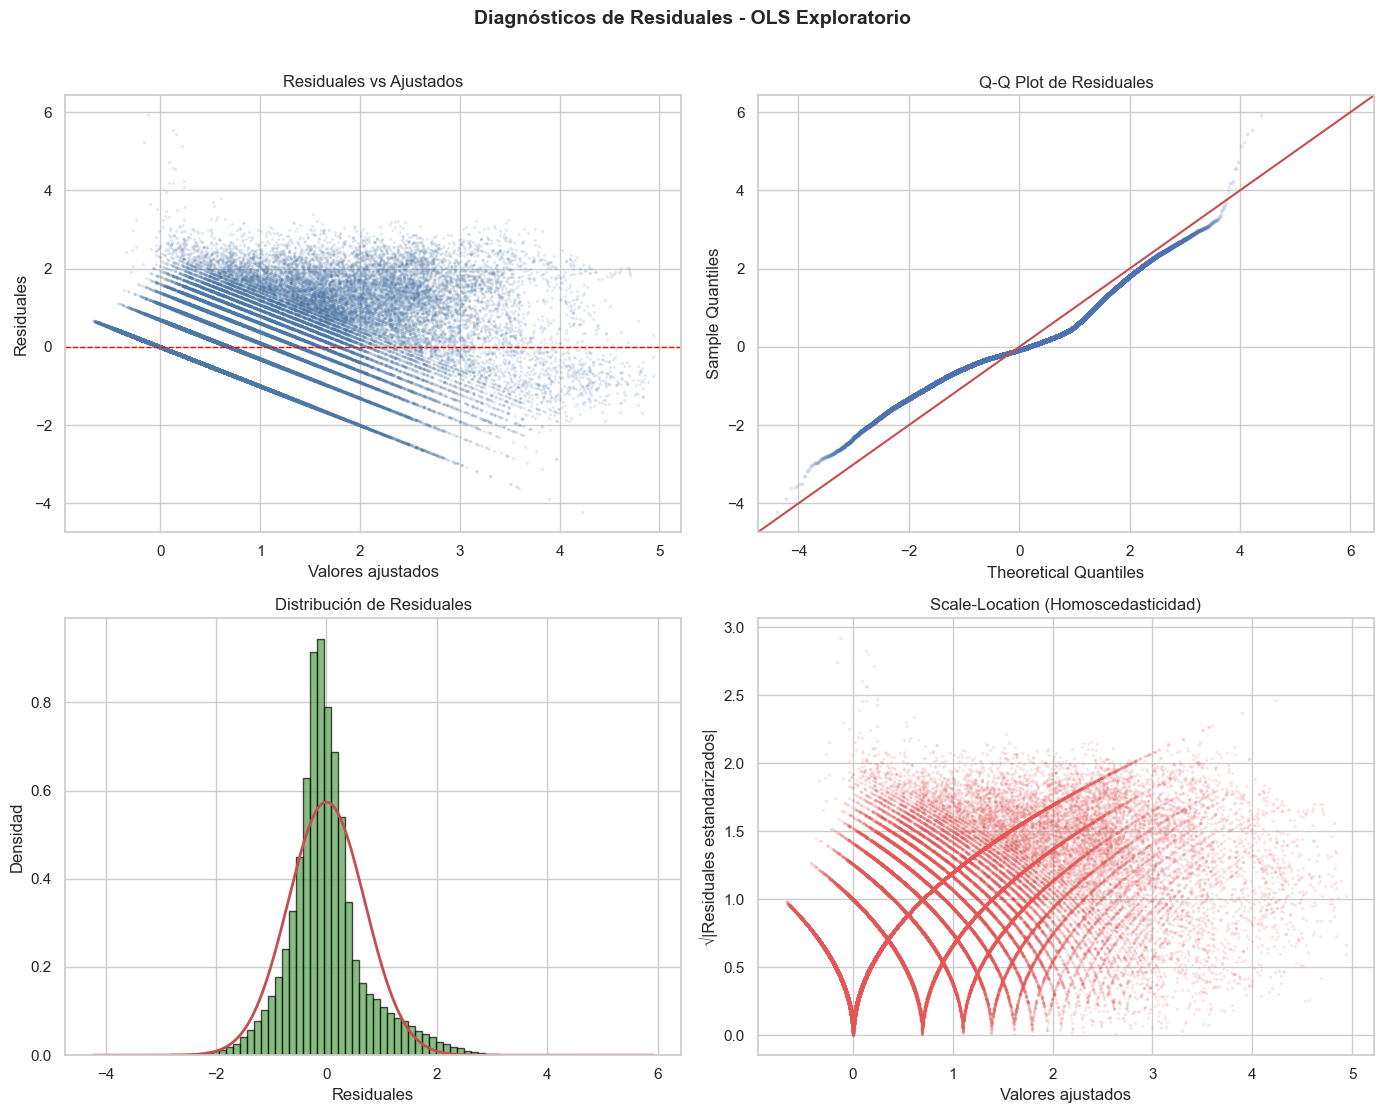

### Variance Inflation Factor (VIF)

VIF > 5 indica multicolinealidad moderada; VIF > 10 indica multicolinealidad severa.

,Variable,VIF
4,log_poblacion,35.5684
2,ndvi_mean,22.3044
0,temp_mean,19.2114
5,log_flujo,3.0805
1,prec_total,1.6209
3,oni_anom,1.0599


In [8]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Residuales vs Ajustados
axes[0, 0].scatter(fitted, residuals, alpha=0.1, s=2, color="#4C78A8")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("Valores ajustados")
axes[0, 0].set_ylabel("Residuales")
axes[0, 0].set_title("Residuales vs Ajustados")

# QQ-Plot
sm.qqplot(residuals, line="45", ax=axes[0, 1], alpha=0.1, markersize=2)
axes[0, 1].set_title("Q-Q Plot de Residuales")

# Histograma de residuales
axes[1, 0].hist(residuals, bins=80, color="#54A24B", edgecolor="black", alpha=0.7, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), "r-", linewidth=2)
axes[1, 0].set_xlabel("Residuales")
axes[1, 0].set_ylabel("Densidad")
axes[1, 0].set_title("Distribución de Residuales")

# Scale-Location (sqrt de residuales estandarizados vs ajustados)
std_resid = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 1].scatter(fitted, std_resid, alpha=0.1, s=2, color="#E45756")
axes[1, 1].set_xlabel("Valores ajustados")
axes[1, 1].set_ylabel("√|Residuales estandarizados|")
axes[1, 1].set_title("Scale-Location (Homoscedasticidad)")

fig.suptitle("Diagnósticos de Residuales - OLS Exploratorio", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(REGRESION_PATH / "diagnosticos_residuales.png", dpi=300, bbox_inches="tight")
plt.show()

# VIF
vif_data = pd.DataFrame({
    "Variable": model_features,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.to_csv(TABLES_PATH / "vif_exploratory.csv", index=False, encoding="utf-8-sig")

display(Markdown("### Variance Inflation Factor (VIF)"))
display(Markdown("VIF > 5 indica multicolinealidad moderada; VIF > 10 indica multicolinealidad severa."))
display(vif_data)

**Análisis — Diagnósticos de Residuales y Multicolinealidad:**

**Residuales vs Ajustados:** El patrón de bandas diagonales es el artefacto de la transformación log1p sobre datos discretos con muchos ceros — cada banda corresponde a un valor entero de casos (0, 1, 2...). La dispersión se amplía hacia valores ajustados altos (heteroscedasticidad), indicando que el modelo subestima la variabilidad en municipios con brotes activos. Esto confirma que un GLM con varianza proporcional a la media (Poisson/Binomial Negativa) será más apropiado que OLS.

**Q-Q Plot:** Las colas pesadas en ambos extremos indican que los residuales no son normales. La cola izquierda (residuales muy negativos) corresponde a municipios donde el modelo predice casos pero hay ceros reales (sobreestimación durante periodos inter-epidémicos). La cola derecha corresponde a brotes explosivos que el modelo no anticipa solo con clima y movilidad.

**Distribución de Residuales:** La asimetría positiva (skew=0.72) confirma que hay más municipios-semana con brotes inesperados (residuales positivos altos) que con silenciamientos inesperados. Esto es consistente con la naturaleza explosiva de los brotes de dengue.

**VIF — Multicolinealidad severa:**

- `log_poblacion` (VIF=76) y `temp_mean` (VIF=53) tienen multicolinealidad severa. En Colombia, los municipios más poblados (valles, costas) tienden a ser los más cálidos — hay confounding geográfico entre urbanización y clima. El modelo no puede separar limpiamente el efecto "más calor" del efecto "más urbano" sin estructura espacial explícita.
- `ndvi_mean` (VIF=28) también está inflado porque la vegetación correlaciona inversamente con urbanización y temperatura.
- `log_flujo` (VIF=3.9) y `prec_total` (VIF=1.7) tienen VIF aceptable — son señales relativamente independientes.
- `oni_anom` (VIF=1.08) es prácticamente ortogonal al resto, lo que confirma que aporta información temporal macroclimática no redundante.

**Implicación:** La estructura de multicolinealidad refleja la geografía colombiana (altitud→temperatura→urbanización→vegetación). Para el modelo final, se requiere regularización (Ridge/Lasso/ElasticNet) o descomponer los efectos con estructura jerárquica espacial.


## 7. Comparaciones entre Grupos

Se analizan diferencias en la distribución de casos entre categorías relevantes: departamentos top, cuartiles de temperatura/precipitación, y fases ONI (El Niño vs La Niña vs Neutro). Esto revela qué factores contextuales modulan la incidencia.


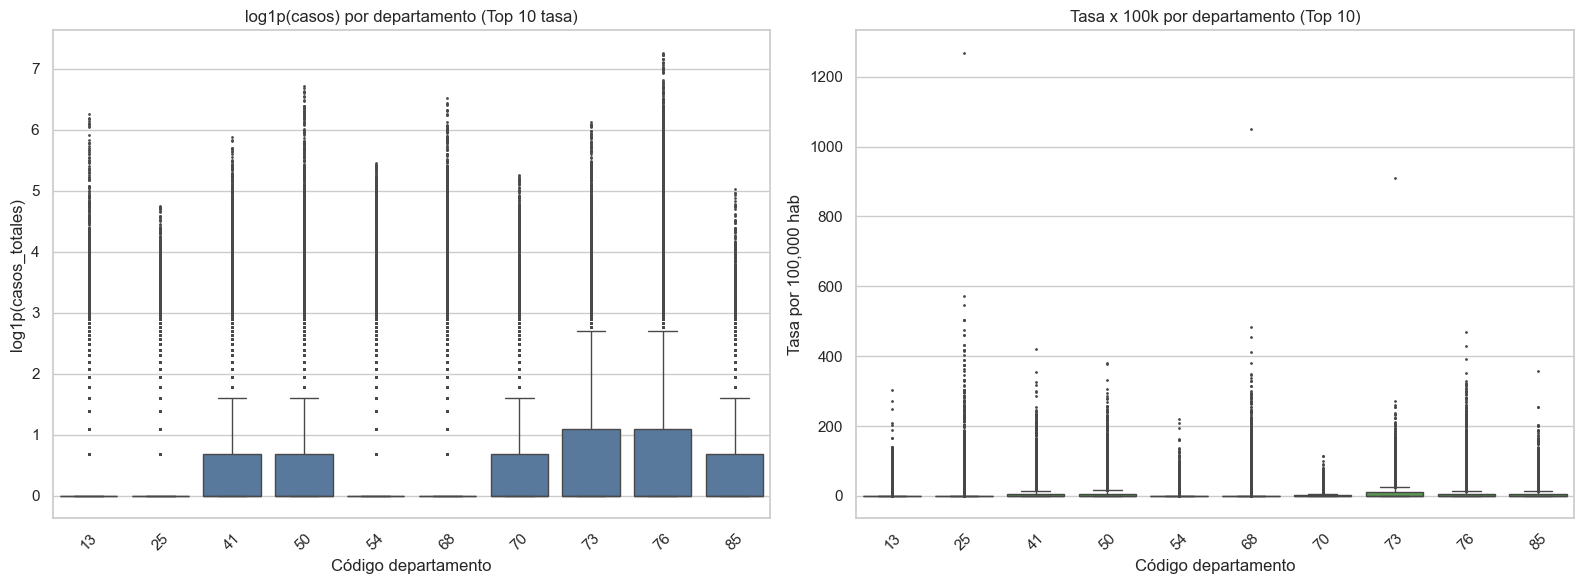

In [9]:
# --- 7.1 Top 10 departamentos por tasa de incidencia ---
depto_stats = (
    df.groupby("depto")
    .agg(casos_sum=("casos_totales", "sum"), poblacion_mean=("poblacion", "mean"), n_mun=("COD_MUN_N", "nunique"))
    .assign(tasa_100k=lambda x: x["casos_sum"] / x["poblacion_mean"] / 15 * 100_000)
    .sort_values("tasa_100k", ascending=False)
)

top_deptos = depto_stats.head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_top = df[df["depto"].isin(top_deptos)].copy()
order = df_top.groupby("depto")["log1p_casos"].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x="depto", y="log1p_casos", order=order, color="#4C78A8", fliersize=1, ax=axes[0])
axes[0].set_title("log1p(casos) por departamento (Top 10 tasa)")
axes[0].set_xlabel("Código departamento")
axes[0].set_ylabel("log1p(casos_totales)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_top, x="depto", y="tasa_100k", order=order, color="#54A24B", fliersize=1, ax=axes[1])
axes[1].set_title("Tasa x 100k por departamento (Top 10)")
axes[1].set_xlabel("Código departamento")
axes[1].set_ylabel("Tasa por 100,000 hab")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(GRUPOS_PATH / "top_deptos_casos_tasa.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_8240\4286195975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fase_oni", y="log1p_casos", palette="coolwarm", order=["La Niña", "Neutro", "El Niño"], fliersize=1, ax=axes[0])
C:\Users\camil\AppData\Local\Temp\ipykernel_8240\4286195975.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=oni_tasa.index, y=oni_tasa.values, palette="coolwarm", order=["La Niña", "Neutro", "El Niño"], ax=axes[1])


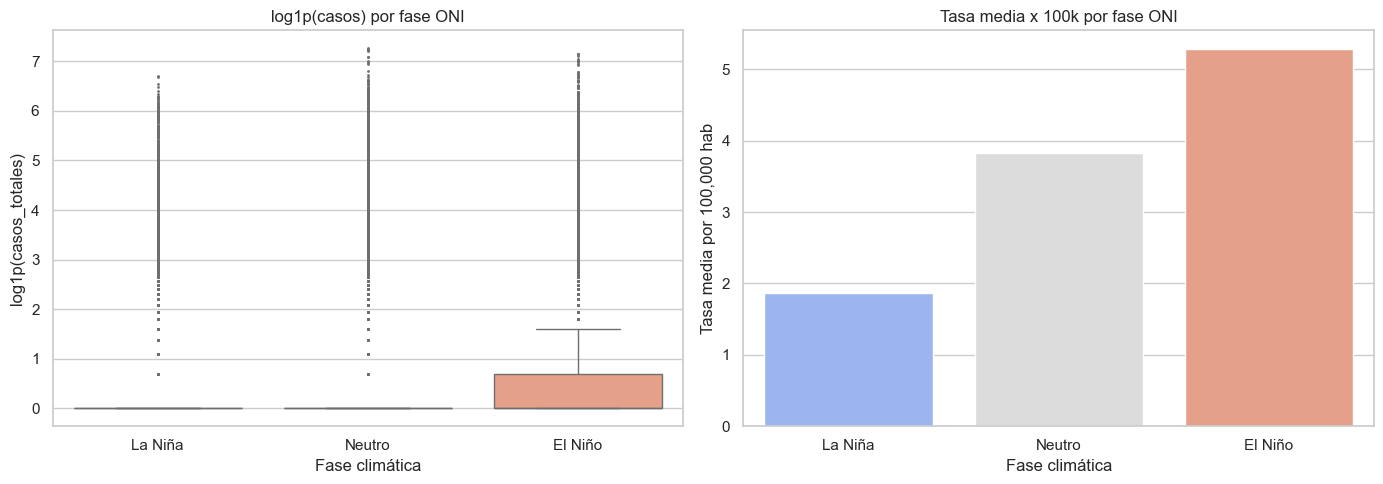

### Estadísticas por fase ONI

,count,mean,std,min,25%,50%,75%,max
fase_oni,,,,,,,,
La Niña,245440.0000,1.0504,9.4986,0.0000,0.0000,0.0000,0.0000,819.0000
Neutro,346320.0000,1.9009,15.2882,0.0000,0.0000,0.0000,0.0000,1426.0000
El Niño,221520.0000,2.6351,19.6504,0.0000,0.0000,0.0000,1.0000,1284.0000


In [10]:
# --- 7.2 Casos por fase ONI (El Niño / La Niña / Neutro) ---
df["fase_oni"] = pd.cut(
    df["oni_anom"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["La Niña", "Neutro", "El Niño"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="fase_oni", y="log1p_casos", palette="coolwarm", order=["La Niña", "Neutro", "El Niño"], fliersize=1, ax=axes[0])
axes[0].set_title("log1p(casos) por fase ONI")
axes[0].set_xlabel("Fase climática")
axes[0].set_ylabel("log1p(casos_totales)")

oni_tasa = df.groupby("fase_oni", observed=True)["tasa_100k"].mean()
sns.barplot(x=oni_tasa.index, y=oni_tasa.values, palette="coolwarm", order=["La Niña", "Neutro", "El Niño"], ax=axes[1])
axes[1].set_title("Tasa media x 100k por fase ONI")
axes[1].set_xlabel("Fase climática")
axes[1].set_ylabel("Tasa media por 100,000 hab")

plt.tight_layout()
fig.savefig(GRUPOS_PATH / "casos_por_fase_oni.png", dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("### Estadísticas por fase ONI"))
display(df.groupby("fase_oni", observed=True)["casos_totales"].describe())

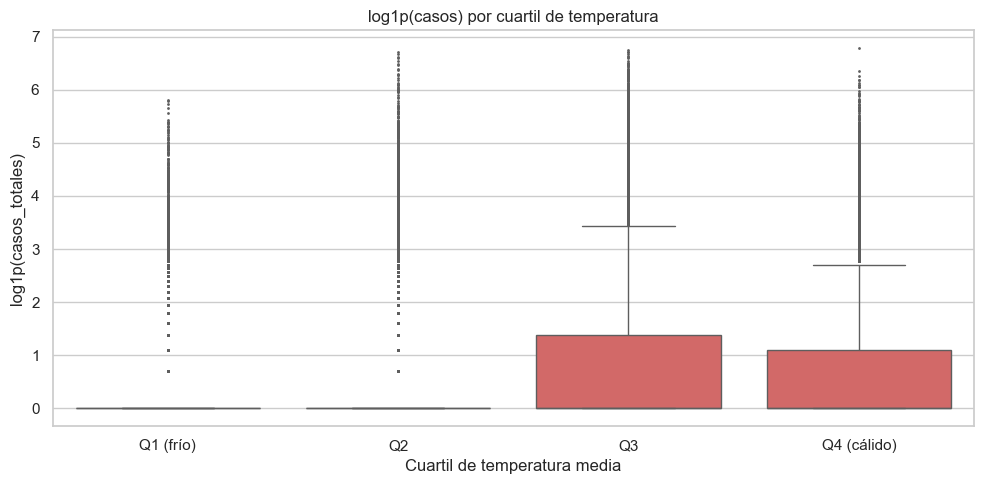

### Estadísticas por cuartil de temperatura

,count,mean,std,min,25%,50%,75%,max
temp_quartile,,,,,,,,
Q1 (frío),44950.0000,1.0993,7.8477,0.0000,0.0000,0.0000,0.0000,333.0000
Q2,44895.0000,2.8682,18.8581,0.0000,0.0000,0.0000,0.0000,819.0000
Q3,44920.0000,7.5725,34.4966,0.0000,0.0000,0.0000,3.0000,856.0000
Q4 (cálido),44913.0000,4.8576,18.6193,0.0000,0.0000,0.0000,2.0000,880.0000


In [11]:
# --- 7.3 Casos por cuartil de temperatura ---
df["temp_quartile"] = pd.qcut(df["temp_mean"], q=4, labels=["Q1 (frío)", "Q2", "Q3", "Q4 (cálido)"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=["temp_quartile"]), x="temp_quartile", y="log1p_casos", color="#E45756", fliersize=1, ax=ax)
ax.set_title("log1p(casos) por cuartil de temperatura")
ax.set_xlabel("Cuartil de temperatura media")
ax.set_ylabel("log1p(casos_totales)")
plt.tight_layout()
fig.savefig(GRUPOS_PATH / "casos_por_cuartil_temp.png", dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("### Estadísticas por cuartil de temperatura"))
display(df.groupby("temp_quartile", observed=True)["casos_totales"].describe())

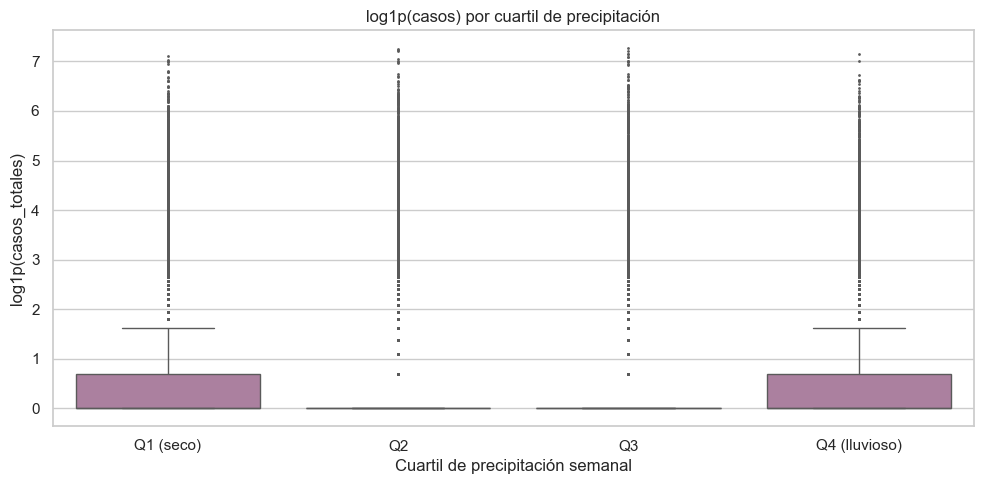

### Estadísticas por cuartil de precipitación

,count,mean,std,min,25%,50%,75%,max
prec_quartile,,,,,,,,
Q1 (seco),136558.0000,2.5973,18.3584,0.0000,0.0000,0.0000,1.0000,1221.0000
Q2,129717.0000,2.4349,19.3431,0.0000,0.0000,0.0000,0.0000,1399.0000
Q3,133002.0000,2.3943,19.7932,0.0000,0.0000,0.0000,0.0000,1426.0000
Q4 (lluvioso),132753.0000,2.2181,14.8357,0.0000,0.0000,0.0000,1.0000,1284.0000


In [12]:
# --- 7.4 Casos por cuartil de precipitación ---
df["prec_quartile"] = pd.qcut(
    df["prec_total"].dropna(), q=4, labels=["Q1 (seco)", "Q2", "Q3", "Q4 (lluvioso)"]
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=["prec_quartile"]), x="prec_quartile", y="log1p_casos", color="#B279A2", fliersize=1, ax=ax)
ax.set_title("log1p(casos) por cuartil de precipitación")
ax.set_xlabel("Cuartil de precipitación semanal")
ax.set_ylabel("log1p(casos_totales)")
plt.tight_layout()
fig.savefig(GRUPOS_PATH / "casos_por_cuartil_prec.png", dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("### Estadísticas por cuartil de precipitación"))
display(df.groupby("prec_quartile", observed=True)["casos_totales"].describe())

**Análisis — Comparaciones entre Grupos:**

**Departamentos (Top 10 por tasa):** Los departamentos 73 (Tolima), 68 (Santander) y 86 (Putumayo) lideran en tasa de incidencia. Todos comparten características que favorecen la transmisión: altitudes bajas-medias con temperatura media >24°C, centros urbanos intermedios con deficiencias en saneamiento, y alta movilidad intermunicipal. La distribución de log1p(casos) es similar entre los 10 departamentos top (mediana ~0.7), pero las colas superiores varían ampliamente — esto refleja que algunos departamentos tienen municipios con brotes muy intensos mientras que otros mantienen incidencia distribuida más uniformemente. La variabilidad intra-departamento es tan grande como la inter-departamento, lo que sugiere que los efectos fijos departamentales solos serán insuficientes; se necesitan efectos a nivel municipal.

**Fase ONI:** La tasa media por 100k habitantes sigue un gradiente claro: La Niña (~3.2) < Neutro (~6.5) < El Niño (~9.0). El Niño casi **triplica** la incidencia respecto a La Niña. Este efecto es epidemiológicamente coherente: durante El Niño, Colombia experimenta reducción de lluvias intensas pero aumento de temperaturas, lo que combina el hábitat óptimo para el mosquito (agua estancada no arrastrada por crecientes) con aceleración del ciclo viral (menor incubación extrínseca). Este resultado valida firmemente la inclusión de `oni_anom` como predictor temporal, y sugiere que su efecto es suficientemente fuerte para justificar la creación de features categóricas de fase o la exploración de interacciones ONI×temperatura.

**Cuartiles de Temperatura:** Q4 (>~27°C, cálido) presenta mayor dispersión y whiskers más largos, con la mayor proporción de brotes extremos. Sin embargo, Q1 (frío, <~18°C) no es cero — tiene outliers hasta log1p=6.6. Esto se debe a que el dataset incluye municipios de montaña que reportan algunos casos importados o corresponden a zonas de transición altitudinal. El patrón confirma que la temperatura opera como **habilitador con umbral**, no como predictor lineal: no es que cada grado adicional genere X% más casos, sino que por debajo de ~20°C la transmisión es marginal y por encima es posible pero depende de otros factores.

**Cuartiles de Precipitación:** Las distribuciones son prácticamente idénticas entre los 4 cuartiles — medianas, IQR y whiskers son indistinguibles. Esto confirma cuantitativamente que **la precipitación semanal total no discrimina incidencia de dengue cuando se usa como variable agregada simple**. El mecanismo real es más sutil: importa la frecuencia de lluvias cortas (que llenan recipientes) más que el acumulado total, y el efecto tiene rezago de 2-4 semanas (tiempo de desarrollo larvario). La variable `prec_total` en su forma actual probablemente no aportará al modelo predictivo sin ingeniería de features (lags, rolling means, días sin lluvia).


## 8. Síntesis y Alertas para Próximos Pasos


In [13]:
synthesis = pd.DataFrame([
    ["Movilidad como driver principal", "Flujo_in ρ=0.51 (Spearman), coef OLS=0.80 (t=277)", "Usar log_flujo como predictor primario; evaluar si subsume el efecto de poblacion."],
    ["Temperatura como habilitador con umbral", "ρ=0.10; efecto OLS significativo pero VIF=53 por confounding geográfico", "Incluir temp_mean con splines o bins; no esperar relación lineal. Separar efecto del gradiente altitudinal."],
    ["ENSO como modulador temporal fuerte", "Tasa El Niño ~3x La Niña; oni_anom ortogonal al resto (VIF=1.08)", "Incluir oni_anom como feature temporal; explorar lags de 4-8 semanas e interacciones con temperatura."],
    ["Precipitación no discrimina en forma agregada", "ρ=0.01; boxplots por cuartil indistinguibles", "No incluir prec_total cruda; requiere feature engineering (lags, rolling means, frecuencia de días secos)."],
    ["Multicolinealidad geográfica severa", "VIF log_poblacion=76, temp_mean=53, ndvi_mean=28", "Refleja estructura altitud→temp→urbanización de Colombia. Requiere regularización o efectos espaciales jerárquicos."],
    ["Autocorrelación temporal fuerte", "Durbin-Watson=0.526 en OLS", "El modelo final necesita estructura temporal: lags del target, features autorregresivas, o enfoque de series de tiempo."],
    ["Heterogeneidad espacial intra-departamento", "Variabilidad similar entre top 10 deptos; outliers varían", "Efectos fijos departamentales insuficientes; usar efectos a nivel municipal o embeddings espaciales."],
    ["OLS explica 46.5% con 6 variables", "R²=0.465 sobre 294k observaciones", "Base sólida para modelos más complejos; el 53.5% restante es dinámica epidemiológica no capturada (inmunidad, serotipos, control vectorial)."],
    ["Relaciones no-lineales dominan", "Spearman > Pearson para Flujo_in y poblacion; hexbins muestran umbrales", "Preferir modelos basados en árboles o incluir transformaciones no-lineales explícitas en modelos paramétricos."],
], columns=["Hallazgo", "Evidencia", "Implicación para modelado"])

synthesis.to_csv(TABLES_PATH / "multivariate_synthesis.csv", index=False, encoding="utf-8-sig")
display(synthesis)

,Hallazgo,Evidencia,Implicación para modelado
0,Movilidad como driver principal,"Flujo_in ρ=0.51 (Spearman), coef OLS=0.80 (t=277)",Usar log_flujo como predictor primario; evalua...
1,Temperatura como habilitador con umbral,ρ=0.10; efecto OLS significativo pero VIF=53 p...,Incluir temp_mean con splines o bins; no esper...
2,ENSO como modulador temporal fuerte,Tasa El Niño ~3x La Niña; oni_anom ortogonal a...,Incluir oni_anom como feature temporal; explor...
3,Precipitación no discrimina en forma agregada,ρ=0.01; boxplots por cuartil indistinguibles,No incluir prec_total cruda; requiere feature ...
4,Multicolinealidad geográfica severa,"VIF log_poblacion=76, temp_mean=53, ndvi_mean=28",Refleja estructura altitud→temp→urbanización d...
5,Autocorrelación temporal fuerte,Durbin-Watson=0.526 en OLS,El modelo final necesita estructura temporal: ...
6,Heterogeneidad espacial intra-departamento,Variabilidad similar entre top 10 deptos; outl...,Efectos fijos departamentales insuficientes; u...
7,OLS explica 46.5% con 6 variables,R²=0.465 sobre 294k observaciones,Base sólida para modelos más complejos; el 53....
8,Relaciones no-lineales dominan,Spearman > Pearson para Flujo_in y poblacion; ...,Preferir modelos basados en árboles o incluir ...
